#### Libraries

In [12]:
import pandas as pd
import numpy as np
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, KFold

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, roc_auc_score, log_loss

#### Load the Dataset

In [13]:
%store -r X_train_scaled
%store -r X_test_scaled
%store -r X_scaled
%store -r y_train
%store -r y_test
%store -r y_dataset

#### Logistic-Regression

In [14]:
log_reg = LogisticRegression(
    C = 10, 
    solver = 'liblinear', 
    max_iter = 1000, 
    multi_class = 'auto',
    penalty = 'l1' 
)

# Convert the target variable to a 1D array using ravel()
y_train_array = y_train.values.ravel()

log_reg.fit(X_train_scaled, y_train_array)

LogisticRegression(C=10, max_iter=1000, penalty='l1', solver='liblinear')

##### One vs Rest

In [15]:
multiclass_model = OneVsRestClassifier(log_reg)

# Train the multiclass classifier
multiclass_model.fit(X_train_scaled, y_train_array)

OneVsRestClassifier(estimator=LogisticRegression(C=10, max_iter=1000,
                                                 penalty='l1',
                                                 solver='liblinear'))

#### Evaluation on Training Data

In [16]:
y_train_pred = multiclass_model.predict(X_train_scaled)
y_train_pred_proba = multiclass_model.predict_proba(X_train_scaled)

# Precision
multi_precision_train = precision_score(y_train_array, y_train_pred, average='weighted', zero_division=1)

# Recall
multi_recall_train = recall_score(y_train_array, y_train_pred, average='weighted')

# F1-Score
multi_f1_train = f1_score(y_train_array, y_train_pred, average='weighted')

# Accuracy
multi_accuracy_train = accuracy_score(y_train_array, y_train_pred)

# Log Loss
multi_log_loss_value_train = log_loss(y_train_array, y_train_pred_proba)

# Confusion Matrix
multi_conf_matrix_train = confusion_matrix(y_train_array, y_train_pred)

# AROC Curve
multi_roc_auc_train = roc_auc_score(y_train_array, y_train_pred_proba, multi_class='ovr', labels=np.unique(y_train_array))

# Evaluation Metrics
print(f'Logistic Regression Training Confusion Matrix:\n{multi_conf_matrix_train}')
print()
print(f'Logistic Regression Training Accuracy: {multi_accuracy_train}')
print(f'Logistic Regression Training F1-Score: {multi_f1_train}')
print(f'Logistic Regression Training Precision: {multi_precision_train}')
print(f'Logistic Regression Training Recall: {multi_recall_train}')
print(f'Logistic Regression Training Area Under the ROC Curve (AROC): {multi_roc_auc_train}')
print(f'Logistic Regression Training Log Loss: {multi_log_loss_value_train}')

Logistic Regression Training Confusion Matrix:
[[100   0   0   0]
 [  0 153   0   0]
 [  0   0 149   0]
 [  0   0   0 198]]

Logistic Regression Training Accuracy: 1.0
Logistic Regression Training F1-Score: 1.0
Logistic Regression Training Precision: 1.0
Logistic Regression Training Recall: 1.0
Logistic Regression Training Area Under the ROC Curve (AROC): 1.0
Logistic Regression Training Log Loss: 0.2421883519609157


#### Evaluation on Test Data

In [17]:
y_test_pred = multiclass_model.predict(X_test_scaled)
y_test_pred_proba = multiclass_model.predict_proba(X_test_scaled)

# Precision
multi_precision_test = precision_score(y_test, y_test_pred, average='weighted', zero_division=1)
%store multi_precision_test

# Recall
multi_recall_test = recall_score(y_test, y_test_pred, average='weighted')
%store multi_recall_test

# F1-Score
multi_f1_test = f1_score(y_test, y_test_pred, average='weighted')
%store multi_f1_test

# Accuracy
multi_accuracy_test = accuracy_score(y_test, y_test_pred)
%store multi_accuracy_test

# Log Loss
multi_log_loss_value_test = log_loss(y_test, y_test_pred_proba)
%store multi_log_loss_value_test

# Confusion Matrix
multi_conf_matrix_test = confusion_matrix(y_test, y_test_pred)
%store multi_conf_matrix_test

# AROC Curve
multi_roc_auc_test = roc_auc_score(y_test, y_test_pred_proba, multi_class='ovr', labels=np.unique(y_test))
%store multi_roc_auc_test

# Evaluation Metrics
print(f'Logistic Regression Testing Confusion Matrix:\n{multi_conf_matrix_test}')
print()
print(f'Logistic Regression Testing Accuracy: {multi_accuracy_test}')
print(f'Logistic Regression Testing F1-Score: {multi_f1_test}')
print(f'Logistic Regression Testing Precision: {multi_precision_test}')
print(f'Logistic Regression Testing Recall: {multi_recall_test}')
print(f'Logistic Regression Testing Log Loss: {multi_log_loss_value_test}')
print(f'Logistic Regression Testing Area Under the ROC Curve (AROC): {multi_roc_auc_test}')

Stored 'multi_precision_test' (float64)
Stored 'multi_recall_test' (float64)
Stored 'multi_f1_test' (float64)
Stored 'multi_accuracy_test' (float)
Stored 'multi_log_loss_value_test' (float)
Stored 'multi_conf_matrix_test' (ndarray)
Stored 'multi_roc_auc_test' (float64)
Logistic Regression Testing Confusion Matrix:
[[25  0  0  0]
 [15  3  7  0]
 [ 0  0 25  0]
 [ 0  0  0 25]]

Logistic Regression Testing Accuracy: 0.78
Logistic Regression Testing F1-Score: 0.715177366493156
Logistic Regression Testing Precision: 0.8515625
Logistic Regression Testing Recall: 0.78
Logistic Regression Testing Log Loss: 1.0716095328592754
Logistic Regression Testing Area Under the ROC Curve (AROC): 0.8778666666666666


### Plot Results

#### Confusion Matrix

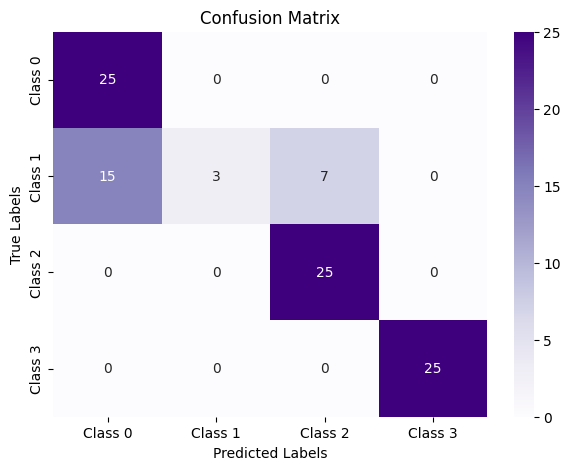

In [18]:
# Plot confusion matrix 
plt.figure(figsize=(7, 5))
sns.heatmap(multi_conf_matrix_test, annot=True, fmt='g', cmap='Purples', xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#### Receiver Operating Characteristic (ROC) Curve

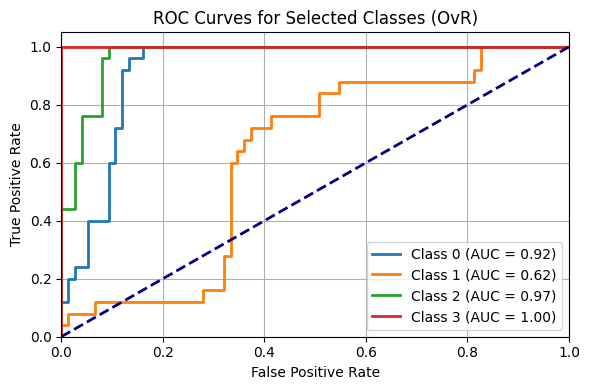

In [19]:
selected_classes = [0, 1, 2, 3]
plt.figure(figsize=(6, 4))

for class_label in selected_classes:
    y_test_binary = (y_test == class_label).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_binary, y_test_pred_proba[:, class_label])
    roc_auc = auc(fpr, tpr)
    
    # Customize κάθε κλάση
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})', 
             color=plt.cm.get_cmap('tab10')(class_label), linestyle='-', linewidth=2)

# Plot the diagonal line 
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Selected Classes (OvR)')
plt.legend(loc='lower right')

plt.grid(True)
plt.tight_layout()
plt.show()

#### Precision, Recall, F1 Score, Accuracy

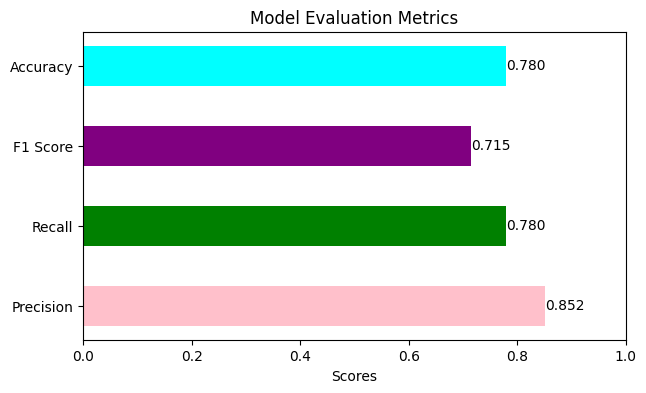

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
scores = [multi_precision_test, multi_recall_test, multi_f1_test, multi_accuracy_test]
bar_width = 0.5

# Plot horizontal bars
bars = ax.barh(metrics, scores, height=bar_width, color = ['pink', 'green', 'purple', 'cyan'])

# Display actual values 
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', 
             va='center', ha='left', color='black')

ax.set_xlabel('Scores')
ax.set_title('Model Evaluation Metrics')

ax.set_xlim(0, 1)
plt.show()

#### 5fold Cross Validation

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
logreg = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, C=10)

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='micro'),
    'recall': make_scorer(recall_score, average='micro'),
    'f1': make_scorer(f1_score, average='micro'),
    'log_loss': make_scorer(log_loss, needs_proba=True),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True, multi_class='ovo') 
}

cv_results = cross_validate(logreg, X_scaled, y_dataset, cv=kf, scoring=scoring, error_score=np.nan)

for fold in range(1, kf.get_n_splits() + 1):
    print(f"Fold {fold} Metrics:")
    print(f"Accuracy: {cv_results['test_accuracy'][fold-1]:.4f}")
    print(f"Precision: {cv_results['test_precision'][fold-1]:.4f}")
    print(f"Recall: {cv_results['test_recall'][fold-1]:.4f}")
    print(f"F1 Score: {cv_results['test_f1'][fold-1]:.4f}")
    print(f"Log Loss: {abs(np.mean(cv_results['test_log_loss'][fold-1])):.4f}")
    print(f"ROC AUC: {cv_results['test_roc_auc'][fold-1]:.4f}")
    print("-" * 100)

mean_metrics = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring}

print("Mean Metrics Across Folds:")
for metric, value in mean_metrics.items():
    if metric == 'test_log_loss':
        value = abs(value)
    print(f"{metric}: {value}")

/home/sarantis/.local/lib/python3.10/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Fold 1 Metrics:
Accuracy: 0.9929
Precision: 0.9929
Recall: 0.9929
F1 Score: 0.9929
Log Loss: 0.2808
ROC AUC: 0.9995
----------------------------------------------------------------------------------------------------
Fold 2 Metrics:
Accuracy: 0.9500
Precision: 0.9500
Recall: 0.9500
F1 Score: 0.9500
Log Loss: 0.3125
ROC AUC: 0.9976
----------------------------------------------------------------------------------------------------
Fold 3 Metrics:
Accuracy: 0.9500
Precision: 0.9500
Recall: 0.9500
F1 Score: 0.9500
Log Loss: 0.3097
ROC AUC: 0.9926
----------------------------------------------------------------------------------------------------
Fold 4 Metrics:
Accuracy: 0.9643
Precision: 0.9643
Recall: 0.9643
F1 Score: 0.9643
Log Loss: 0.2670
ROC AUC: 0.9961
----------------------------------------------------------------------------------------------------
Fold 5 Metrics:
Accuracy: 0.9643
Precision: 0.9643
Recall: 0.9643
F1 Score: 0.9643
Log Loss: 0.2829
ROC AUC: 0.9982
----------------

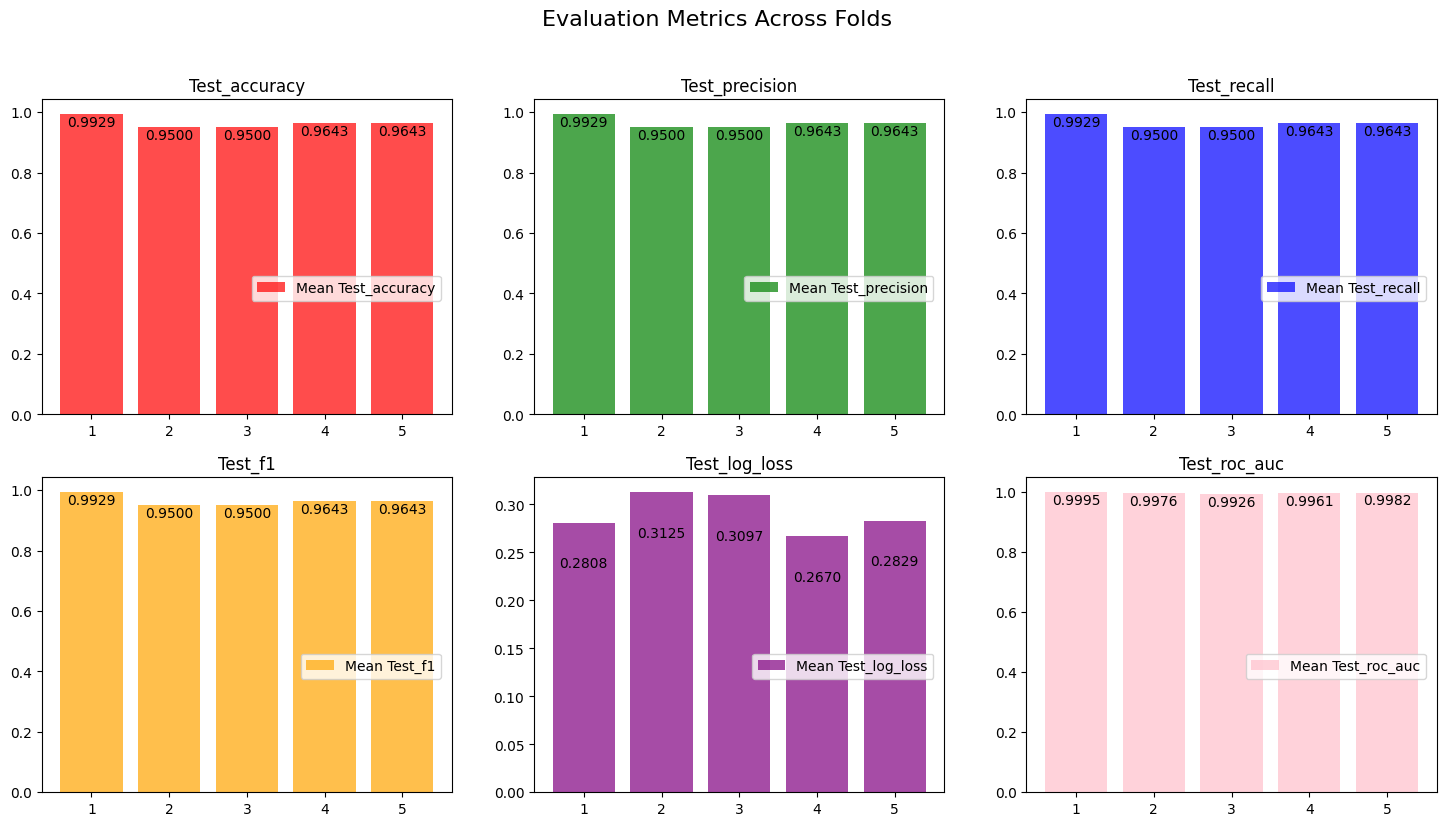

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9))
fig.suptitle('Evaluation Metrics Across Folds', fontsize=16)

# Function for values inside the bars
def add_values(ax, values):
    for i, value in enumerate(values):
        ax.text(i + 1, value - 0.05, f'{value:.4f}', ha='center', va='bottom', color='black')

bar_height = 0.5
metrics_to_plot = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_log_loss', 'test_roc_auc']
colors = ['red', 'green', 'blue', 'orange', 'purple', 'pink']  

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    row = idx // 3
    col = idx % 3

    if metric == 'neg_log_loss':
        metric_values = np.abs(cv_results[f'{metric}'])
    else:
        metric_values = cv_results[f'{metric}']

    bars = axes[row, col].bar(range(1, kf.get_n_splits() + 1), metric_values, color=color, alpha=0.7)
    axes[row, col].set_title(metric.capitalize())
    add_values(axes[row, col], metric_values)

    axes[row, col].legend([f'Mean {metric.capitalize()}'], loc='center right', bbox_to_anchor=(0.99, 0.4))

if len(metrics_to_plot) < 6:
    fig.delaxes(axes[-1, -1])

plt.subplots_adjust(hspace=0.2)
plt.show()